In [1]:
"""
Without Projection
"""


from matplotlib.ticker import LinearLocator
from jax import config, jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
import sys
from functools import partial

# --- Standard Library ---
sys.path.append("../src")

# --- Third-Party Packages ---

# JAX Config
jax.config.update("jax_platform_name", "cpu")
config.update("jax_enable_x64", True)

In [2]:
# --- Local Application / Library Specibcic Imports ---
from configuration.rte1d_settings_ex1_oerfm import get_config
from constraints.continuous1d_oe import (
    OddEvenDecompositionPointwiseBoundaryConstraint1D as BC,
    OddEvenOriginalDecompositionPointwiseInteriorConstraint1D as EQ,
)
from geometry.meshxd_ds import UniformMeshXV
from modules.generator import Sample1D
from modules.solution import OddEvenDecompositionConstructor1D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Mp_j = rte_config.model.Mp["j"]
Mp_r = rte_config.model.Mp["r"]
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXV(domain=domain, strides=strides)
mesh_r = UniformMeshXV(domain=domain, strides=strides)
# print(f"Mp_j: {Mp_j}, Mp_r: {Mp_r} - Jn_j: {Jn["j"]}, Jn_r: {Jn["g"]}")

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_v = jnp.split(jnp.array([0.0, 0.0]), 2, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_v)
# bc_instance = bc.apply(params, dummy_x, dummy_v)

In [6]:
# (3, Mp_j*Jn_j+Mp_r*Jn_r), (Mp_j*Jn_j+Mp_r*Jn_r,)
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, v):
    return partial(rte.apply, params)(x, v)


def bc_fn(x, v):
    return partial(bc.apply, params)(x, v)


def rhs_fn(x, v):

    def q_sym(x, v):
        return 0.5 * (source_fn(x, v) + source_fn(x, -v))

    def q_asym(x, v):
        return 0.5 * (source_fn(x, v) - source_fn(x, -v))

    rhs = jnp.array([
        kn**2 * q_sym(x, v).squeeze(),
        kn * q_asym(x, v).squeeze(),
    ])
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = Sample1D(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode)
xv_int, xv_bcl, xv_bcr = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
)

In [9]:
# Evaluate the functions
bc_left = vmap_bc_fn(*xv_bcl)
bc_right = vmap_bc_fn(*xv_bcr)

In [10]:
eq_int = vmap_eq_fn(*xv_int)

In [11]:
rhs_int = vmap_rhs_fn(*xv_int)

In [12]:
print(f"Boundary: {bc_left.shape}, {bc_right.shape}, Interior: {eq_int.shape}")

Boundary: (64, 128), (64, 128), Interior: (960, 2, 128)


In [13]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, eq_int.reshape(-1, num_unknowns)], axis=0)
vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size = bc_left.shape[0]
vector_b[:bdy_size, 0] = bdy_value["f_l"](xv_bcl[-1])
vector_b[bdy_size: 2 * bdy_size, 0] = bdy_value["f_r"](xv_bcr[-1])
print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (2048, 128), Vector b: (2048, 1)


In [14]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

Matrix A 内存 2.00 MB
Vector b 内存 0.02 MB


In [15]:
vector_U = solve(matrix_A, vector_b, c=regularizer)

print(f"Vector U: {vector_U.shape}")

Vector U: (128, 1)


In [16]:
np.linalg.norm(matrix_A @ vector_U - vector_b) / np.linalg.norm(vector_b)

0.06373826906005609

In [17]:
from numpy.linalg import cond

print(f" Matrix A Condition number: {cond(matrix_A):.6e}")
print(f" Vector b Condition number: {cond(vector_b):.6e}")

 Matrix A Condition number: 4.902018e+12
 Vector b Condition number: 1.000000e+00


In [18]:
# import numpy as np

# # import matplotlib.pyplot as plt

# # 假设 A 是你的矩阵
# U, svals, Vt = np.linalg.svd(matrix_A, full_matrices=False)

# print("前10个奇异值：", svals[:10])
# print("最小奇异值：", svals[-1])
# print("条件数 κ(A) =", svals[0] / svals[-1])

# # 画奇异值谱（对数刻度）
# plt.figure()
# plt.semilogy(svals, marker="o")
# plt.xlabel("Index")
# plt.ylabel("Singular value (log scale)")
# plt.title("Singular Value Spectrum")
# plt.grid(True, which="both")
# plt.show()

In [19]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [20]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)

constructor = OddEvenDecompositionConstructor1D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [21]:
def approx_fn(x, v):
    return partial(constructor.apply, params)(x, v)

In [22]:
# dummy_z = jnp.array([0.7, -0.5])
# dummy_x, dummy_v = jnp.split(dummy_z, 2, axis=0)
# print(f"f({dummy_z}) = {jit(approx_fn)(dummy_x, dummy_v)}")  # 0.15

In [23]:
vmap_approx_fn = vmap(approx_fn)

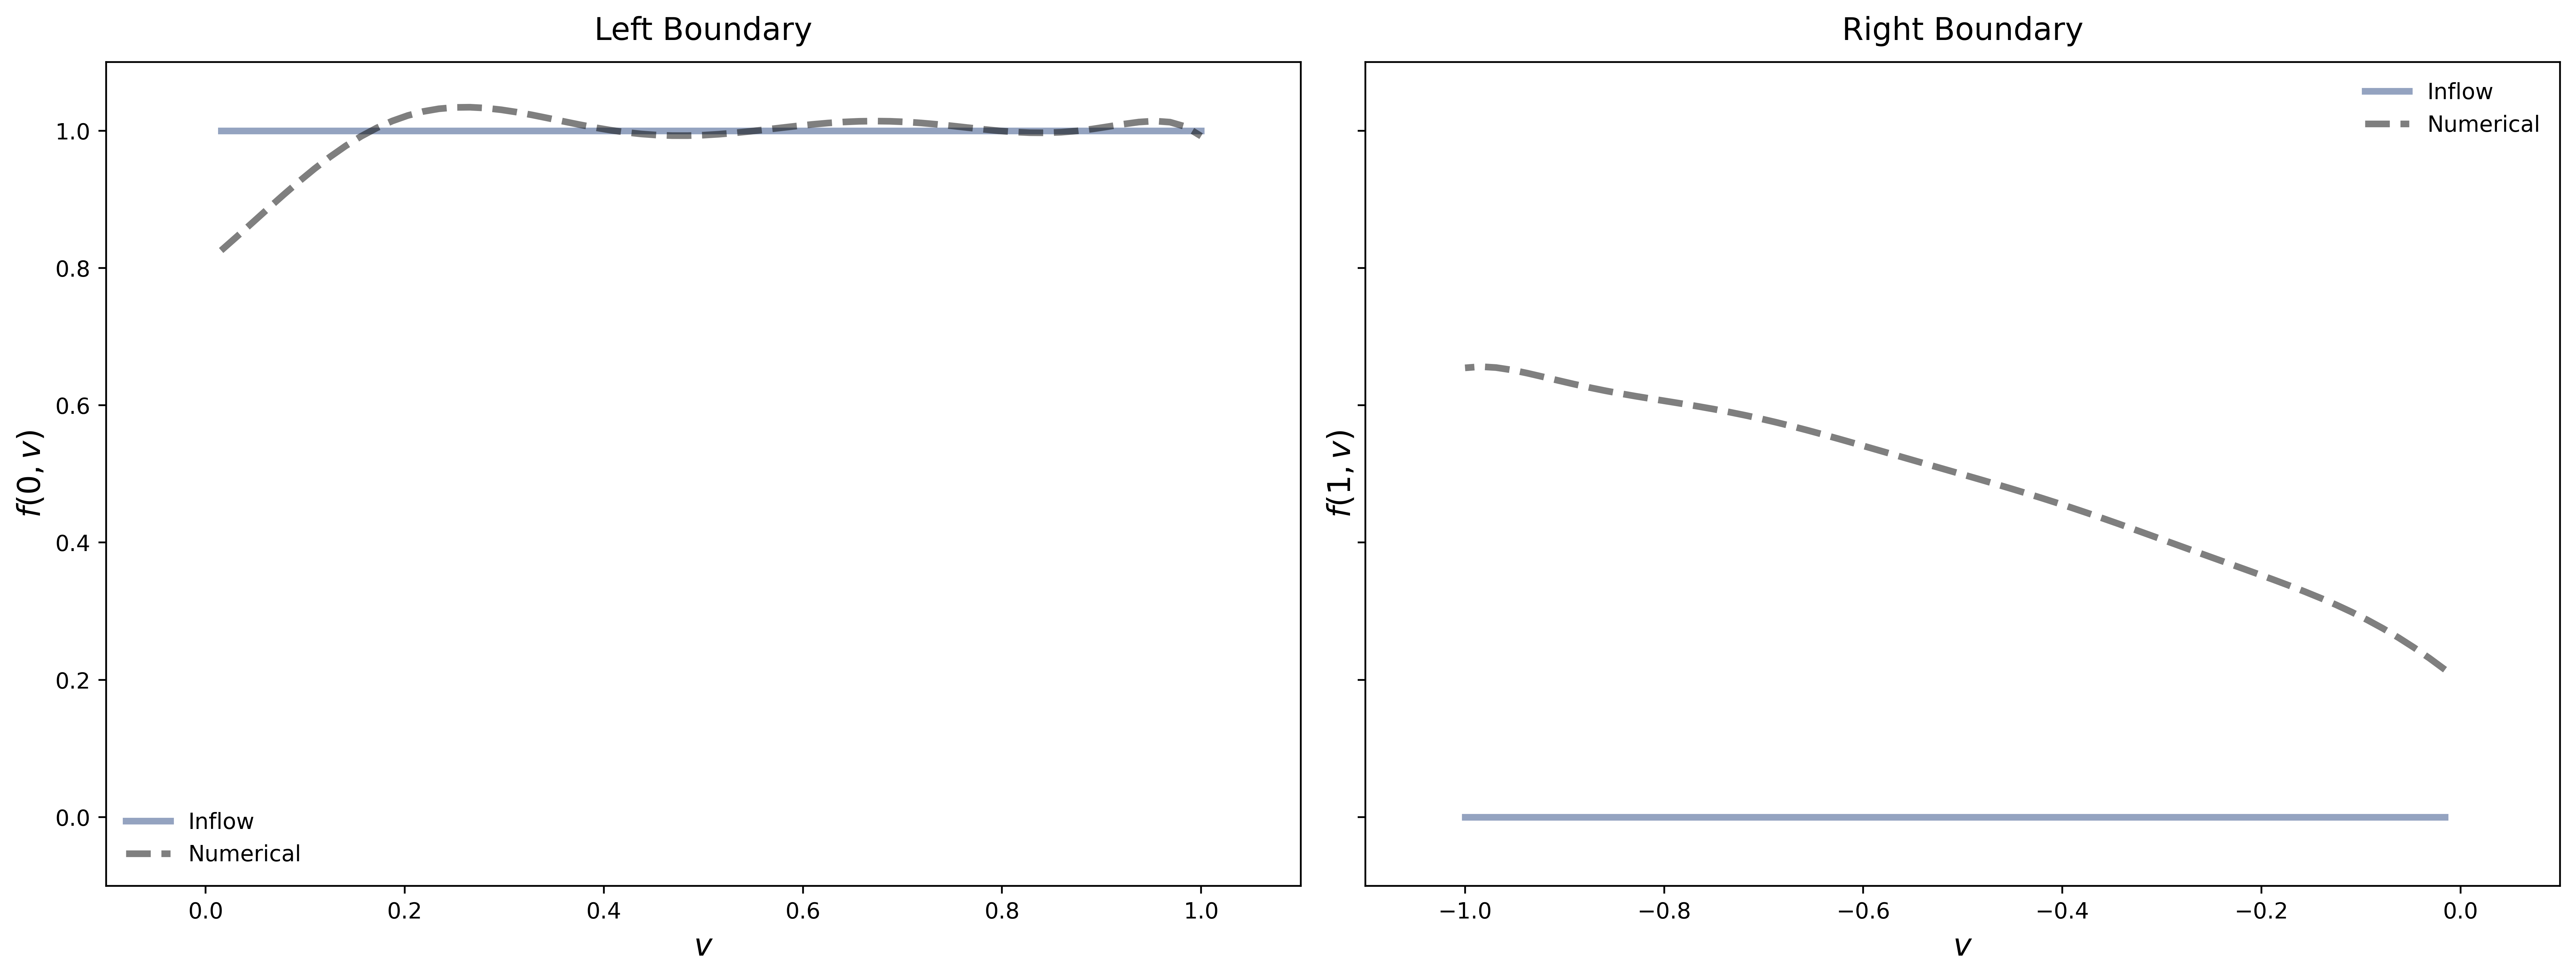

In [24]:
def plot_boundary_solutions():
    """绘制边界解 - 高清一行两列布局"""
    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        dpi=500,
        sharey=True,
        constrained_layout=True,
    )

    # 左边界 (x=0, v > 0)
    v_left = xv_bcl[1]
    f_left = vmap_approx_fn(*xv_bcl)
    f_ex_left = jnp.ones_like(f_left)
    ax1.plot(v_left, f_ex_left, "-", color="#94A3C0",
             linewidth=3, label="Inflow")
    ax1.plot(v_left, f_left, "k--", alpha=0.5, linewidth=3, label="Numerical")
    ax1.set_xlim([-0.1, 1.1])
    ax1.set_ylim([-0.1, 1.1])
    ax1.set_xlabel(r"$v$", fontsize=14)
    ax1.set_ylabel(r"$f(0, v)$", fontsize=14)
    ax1.set_title("Left Boundary", fontsize=14, pad=10)
    # ax1.grid(alpha=0.3, linestyle=":", linewidth=0.8)
    ax1.legend(frameon=False, loc="best")

    # 右边界 (x=1, v < 0)
    v_right = -xv_bcr[1]  # 使用正确的索引获取速度坐标
    f_right = vmap_approx_fn(*xv_bcr)
    f_ex_right = jnp.zeros_like(f_right)
    ax2.plot(v_right, f_ex_right, "-", color="#94A3C0",
             linewidth=3, label="Inflow")
    ax2.plot(v_right, f_right, "k--", alpha=0.5,
             linewidth=3, label="Numerical")
    ax2.set_xlim([-1.1, 0.1])
    ax2.set_ylim([-0.1, 1.1])
    ax2.set_xlabel(r"$v$", fontsize=14)
    ax2.set_ylabel(r"$f(1, v)$", fontsize=14)
    ax2.set_title("Right Boundary", fontsize=14, pad=10)
    # ax2.grid(alpha=0.3, linestyle=":", linewidth=0.8)
    ax2.legend(frameon=False, loc="best")

    # 美化所有子图的边框
    # for ax in (ax1, ax2):
    #     for spine in ax.spines.values():
    #         spine.set_linewidth(1.8)

    # plt.suptitle("Boundary Solutions", fontsize=16, y=1.02)
    plt.show()
    plt.close()


# 使用示例
plot_boundary_solutions()

In [25]:
data = np.load(f"../src/data/rte1d_ex1_ref_{kn:.1e}.npz")
mesh_x, mesh_v, F = data["mesh_x"], data["mesh_v"], data["F"]
X, V = np.meshgrid(mesh_x, mesh_v)
XV = np.stack([X, V], axis=-1)
F_hat = vmap_approx_fn(
    *np.split(XV.reshape(-1, 2), 2, axis=1)).reshape(X.shape)
print(kn, mesh_x.shape, mesh_v.shape, F.shape, F_hat.shape)
# np.savez("../src/data/rte1d_solutions_kn.npz", X=X, V=V, F=F, F_hat=F_hat)

1.0 (511,) (254,) (254, 511) (254, 511)


In [26]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(0.49684089, dtype=float64)

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


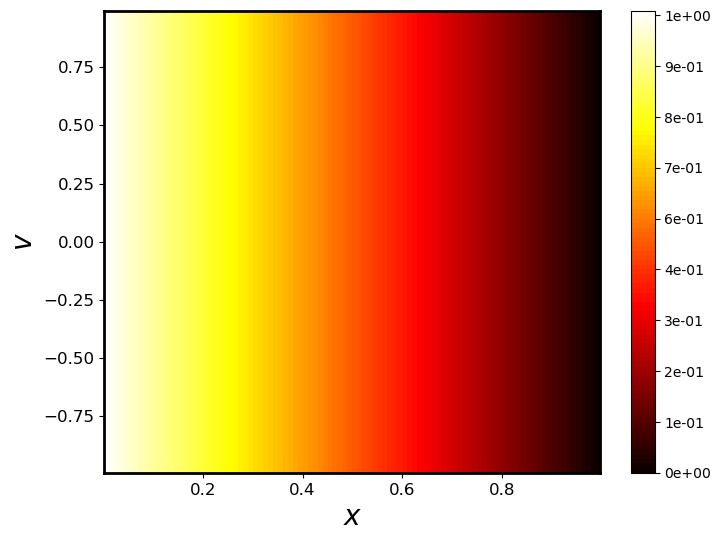

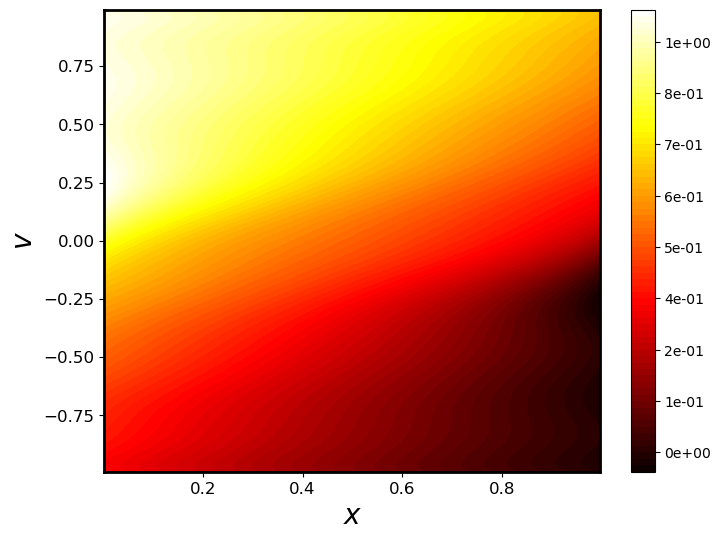

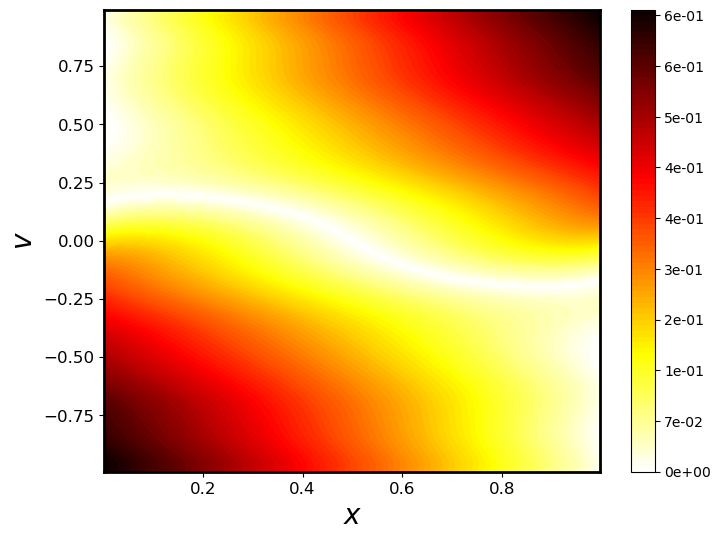

In [27]:
font_format = {"family": "Times New Roman", "size": 20}

# 第一张图：参考解
plt.figure(figsize=(8, 6))
plt.contourf(X, V, F, 100, cmap="hot")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Reference solution", font_format)
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
plt.show()
plt.close()

# 第二张图：OE-APRFM 解
plt.figure(figsize=(8, 6))
plt.contourf(X, V, F_hat, 100, cmap="hot")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
# plt.title("OE-APRFM solution", font_format)
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
plt.show()
plt.close()

# 第三张图：误差
plt.figure(figsize=(8, 6))
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Error", font_format)
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
plt.show()
plt.close()

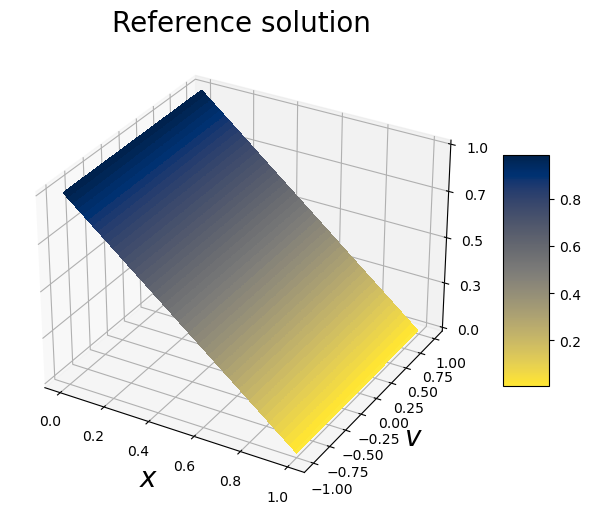

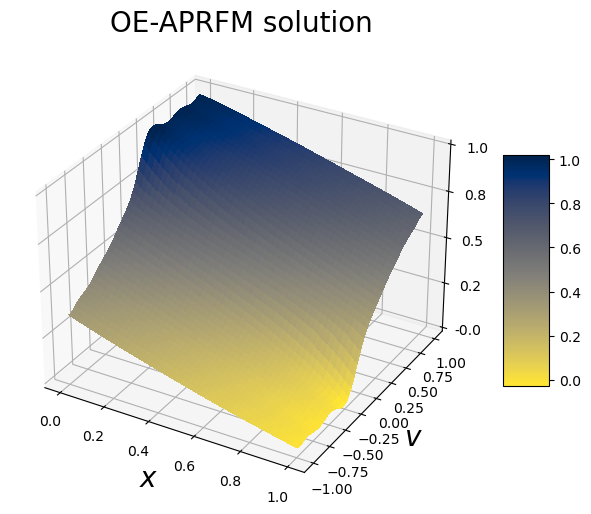

In [28]:
# 第一张图：参考解 3D
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F, cmap="cividis_r",
                         linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.show()
plt.close()

# 第二张图：OE-APRFM 解 3D
fig = plt.figure(figsize=(8, 6))
ax2 = fig.add_subplot(1, 1, 1, projection="3d")
surf2 = ax2.plot_surface(X, V, F_hat, cmap="cividis_r",
                         linewidth=0, antialiased=False)
ax2.set_xlabel(r"$x$", font_format)
ax2.set_ylabel(r"$v$", font_format)
ax2.set_title("OE-APRFM solution", font_format)
ax2.zaxis.set_major_locator(LinearLocator(5))
ax2.zaxis.set_major_formatter("{x:.01f}")
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)
fig.colorbar(surf2, shrink=0.5, aspect=5)
plt.show()
plt.close()

In [29]:
if __name__ == "__main__":
    # 确保numpy数组已定义
    mesh_x_np = np.asarray(mesh_x)
    mesh_v_np = np.asarray(mesh_v)
    F_np = np.asarray(F)
    F_hat_np = np.asarray(F_hat)

    # 确保使用numpy数组
    F = F_np
    F_hat = F_hat_np

    # F_hat和F已经在前面的cell中准备好了
    # 数据格式：(nv, nx)

    print("=" * 70)
    print("数值解精度验证与误差分析")
    print("=" * 70)
    print(f"Solution shape: {F_hat.shape} (nv × nx)")
    print(f"Knudsen Number: {kn}")
    print(f"Mesh: {len(mesh_v_np)} × {len(mesh_x_np)} = {F_hat.size} points")
    print("=" * 70)

    # ========== 1. 全局误差统计 ==========
    print("\n【1. 全局误差统计】")
    error = F - F_hat
    l2_error = np.linalg.norm(error) / np.linalg.norm(F)
    l2_abs = np.linalg.norm(error)
    max_error = np.max(np.abs(error))
    mean_error = np.mean(np.abs(error))

    print(f"  相对L2误差:  {l2_error:.6e}")
    print(f"  绝对L2误差:  {l2_abs:.6e}")
    print(f"  最大点态误差: {max_error:.6e}")
    print(f"  平均绝对误差: {mean_error:.6e}")

    # ========== 2. 边界条件验证 ==========
    print("\n【2. 边界条件验证】")
    mesh_v_1d = np.asarray(mesh_v).flatten()
    idx_pos = mesh_v_1d >= 0
    idx_neg = mesh_v_1d < 0

    # 左边界 x=0, v>0: f(0,v) = 1
    f_left = F_hat[idx_pos, 0]
    bc_left_error = np.abs(f_left - 1.0)
    print(f"  左边界 (x=0, v>0): f = 1")
    print(f"    L2误差:      {np.linalg.norm(bc_left_error):.6e}")
    print(f"    最大误差:    {np.max(bc_left_error):.6e}")
    print(f"    平均误差:    {np.mean(bc_left_error):.6e}")

    # 右边界 x=1, v<0: f(1,v) = 0
    f_right = F_hat[idx_neg, -1]
    bc_right_error = np.abs(f_right - 0.0)
    print(f"  右边界 (x=1, v<0): f = 0")
    print(f"    L2误差:      {np.linalg.norm(bc_right_error):.6e}")
    print(f"    最大误差:    {np.max(bc_right_error):.6e}")
    print(f"    平均误差:    {np.mean(bc_right_error):.6e}")

    # ========== 3. PDE残差验证 ==========
    print("\n【3. 原始PDE残差验证】")
    print("  方程: ε·v·∂_x f = ⟨f⟩ - f - ε·v")

    eps = float(kn)

    # 转置以便沿x方向计算导数
    F_hat_T = F_hat.T  # (nx, nv)

    # 计算 ∂_x f (中心差分)
    dx = mesh_x_np[1] - mesh_x_np[0]
    dfdx = (F_hat_T[2:, :] - F_hat_T[:-2, :]) / (2 * dx)

    # 计算 ⟨f⟩ (速度平均)
    avg_f = 0.5 * np.trapz(F_hat_T, mesh_v_1d, axis=1)
    avg_f_mid = avg_f[1:-1]

    # PDE左端和右端
    lhs_pde = eps * (mesh_v_1d[None, :] * dfdx)
    rhs_pde = avg_f_mid[:, None] - F_hat_T[1:-1, :] - eps * mesh_v_1d[None, :]
    res_pde = lhs_pde - rhs_pde

    pde_l2 = np.linalg.norm(res_pde) / np.sqrt(res_pde.size)
    pde_max = np.max(np.abs(res_pde))
    pde_mean = np.mean(np.abs(res_pde))

    print(f"  L2(残差)/√N:  {pde_l2:.6e}")
    print(f"  最大残差:     {pde_max:.6e}")
    print(f"  平均残差:     {pde_mean:.6e}")

    # ========== 4. Odd-Even分解验证 ==========
    print("\n【4. Odd-Even分解】")
    print("  f = r + ε·j, 其中:")
    print("    r = (f(v) + f(-v))/2  (偶部分)")
    print("    j = (f(v) - f(-v))/(2ε)  (奇部分/ε)")

    # 对于(nv, nx)的数据，通过索引进行分解
    f_pos = F_hat[idx_pos, :]  # (nv_pos, nx)
    f_neg = F_hat[idx_neg, :]  # (nv_neg, nx)
    f_neg_rev = f_neg[::-1, :]  # 反序对应

    r = 0.5 * (f_pos + f_neg_rev)  # 偶部分
    odd_part = 0.5 * (f_pos - f_neg_rev)
    j = odd_part / eps  # 奇部分/ε

    # 检查分解的数值范围
    print(f"\n  数值范围:")
    print(f"    f: [{np.min(F_hat):.6e}, {np.max(F_hat):.6e}]")
    print(f"    r: [{np.min(r):.6e}, {np.max(r):.6e}]")
    print(f"    j: [{np.min(j):.6e}, {np.max(j):.6e}]")
    print(f"    ε·j: [{np.min(eps * j):.6e}, {np.max(eps * j):.6e}]")

    # 验证分解: f = r + ε·j
    f_reconstructed = r + eps * j
    decomp_error = np.linalg.norm(
        f_pos - f_reconstructed) / np.linalg.norm(f_pos)
    print(f"\n  分解验证 (f = r + ε·j):")
    print(f"    相对误差: {decomp_error:.6e}")

    # ========== 5. Odd-Even方程残差 ==========
    print("\n【5. Odd-Even方程残差验证】")

    v_pos_vals = mesh_v_1d[idx_pos]
    nv_pos = len(v_pos_vals)

    # 计算导数 (中心差分)
    drdx = (r[:, 2:] - r[:, :-2]) / (2 * dx)
    djdx = (j[:, 2:] - j[:, :-2]) / (2 * dx)

    r_mid = r[:, 1:-1]
    j_mid = j[:, 1:-1]

    # 计算平均值
    r_mean = 0.5 * np.trapz(r_mid, v_pos_vals, axis=0)
    v_djdx = v_pos_vals[:, None] * djdx
    avg_v_djdx = 0.5 * np.trapz(v_djdx, v_pos_vals, axis=0)

    # 方程 (1): ⟨v·∂_x j⟩ = 0
    res_eq1 = avg_v_djdx
    eq1_l2 = np.linalg.norm(res_eq1) / np.sqrt(res_eq1.size)
    eq1_max = np.max(np.abs(res_eq1))
    eq1_scaled_l2 = np.linalg.norm(eps**2 * res_eq1) / np.sqrt(res_eq1.size)

    print(f"\n  方程(1): ⟨v·∂_x j⟩ = 0")
    print(f"    L2(残差)/√N:       {eq1_l2:.6e}")
    print(f"    最大残差:          {eq1_max:.6e}")
    print(f"    L2(ε²·残差)/√N:    {eq1_scaled_l2:.6e}  (物理尺度)")

    # 方程 (2): ε²(v·∂_x j - ⟨v·∂_x j⟩) + r - ⟨r⟩ = 0
    v_djdx_2d = v_djdx
    avg_v_djdx_2d = avg_v_djdx[None, :]
    res_eq2 = eps**2 * (v_djdx_2d - avg_v_djdx_2d) + (r_mid - r_mean[None, :])
    eq2_l2 = np.linalg.norm(res_eq2) / np.sqrt(res_eq2.size)
    eq2_max = np.max(np.abs(res_eq2))

    print(f"\n  方程(2): ε²(v·∂_x j - ⟨v·∂_x j⟩) + r - ⟨r⟩ = 0")
    print(f"    L2(残差)/√N:       {eq2_l2:.6e}")
    print(f"    最大残差:          {eq2_max:.6e}")
    print(f"    (这是最重要的守恒方程)")

    # 方程 (3): j + v·∂_x r = -v
    v_drdx = v_pos_vals[:, None] * drdx
    res_eq3 = j_mid + v_drdx + v_pos_vals[:, None]
    eq3_l2 = np.linalg.norm(res_eq3) / np.sqrt(res_eq3.size)
    eq3_max = np.max(np.abs(res_eq3))
    eq3_scaled_l2 = np.linalg.norm(eps * res_eq3) / np.sqrt(res_eq3.size)

    print(f"\n  方程(3): j + v·∂_x r = -v")
    print(f"    L2(残差)/√N:       {eq3_l2:.6e}")
    print(f"    最大残差:          {eq3_max:.6e}")
    print(f"    L2(ε·残差)/√N:     {eq3_scaled_l2:.6e}  (物理尺度)")

    # ========== 6. 数值稳定性分析 ==========
    print("\n【6. 数值稳定性分析】")
    print(f"  ⟨r⟩ 的范围: [{np.min(r_mean):.6e}, {np.max(r_mean):.6e}]")
    print(f"  ⟨r⟩ 非零说明: 方程(2)要求 r - ⟨r⟩ = 0, 不要求 ⟨r⟩ = 0")
    print(f"\n  Knudsen数 (ε={eps:.1e}) 的影响:")
    if eps < 1e-10:
        print(f"    j = odd_part/(2ε) → 误差放大 ~10^{int(np.log10(1 / eps))}")
    print(f"    但物理量 ε·j 仍保持正确尺度")

    # ========== 总结 ==========
    print("\n" + "=" * 70)
    print("【验证总结】")
    print("=" * 70)
    print(f"✓ 全局相对L2误差:       {l2_error:.6e}")
    print(f"✓ 左边界条件误差:       {np.linalg.norm(bc_left_error):.6e}")
    print(f"✓ 右边界条件误差:       {np.linalg.norm(bc_right_error):.6e}")
    print(f"✓ PDE残差:             {pde_l2:.6e}")
    print(f"✓ 方程(2)残差(守恒):    {eq2_l2:.6e}")
    print(f"✓ ε²·方程(1)残差:      {eq1_scaled_l2:.6e}")
    print(f"✓ ε·方程(3)残差:       {eq3_scaled_l2:.6e}")
    print("=" * 70)

数值解精度验证与误差分析
Solution shape: (254, 511) (nv × nx)
Knudsen Number: 1.0
Mesh: 254 × 511 = 129794 points

【1. 全局误差统计】
  相对L2误差:  4.968409e-01
  绝对L2误差:  1.032932e+02
  最大点态误差: 6.551842e-01
  平均绝对误差: 2.364409e-01

【2. 边界条件验证】
  左边界 (x=0, v>0): f = 1
    L2误差:      5.253773e-01
    最大误差:    1.918065e-01
    平均误差:    2.424229e-02
  右边界 (x=1, v<0): f = 0
    L2误差:      5.455515e-01
    最大误差:    1.950825e-01
    平均误差:    2.535442e-02

【3. 原始PDE残差验证】
  方程: ε·v·∂_x f = ⟨f⟩ - f - ε·v
  L2(残差)/√N:  5.742896e-01
  最大残差:     1.065046e+00
  平均残差:     4.974052e-01

【4. Odd-Even分解】
  f = r + ε·j, 其中:
    r = (f(v) + f(-v))/2  (偶部分)
    j = (f(v) - f(-v))/(2ε)  (奇部分/ε)

  数值范围:
    f: [-3.462341e-02, 1.032282e+00]
    r: [1.681111e-01, 8.325133e-01]
    j: [1.674668e-03, 3.505225e-01]
    ε·j: [1.674668e-03, 3.505225e-01]

  分解验证 (f = r + ε·j):
    相对误差: 0.000000e+00

【5. Odd-Even方程残差验证】

  方程(1): ⟨v·∂_x j⟩ = 0
    L2(残差)/√N:       7.777742e-04
    最大残差:          7.012793e-03
    L2(ε²·残差)/√N:    7.7777

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman, Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman, Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman, Times New Roman


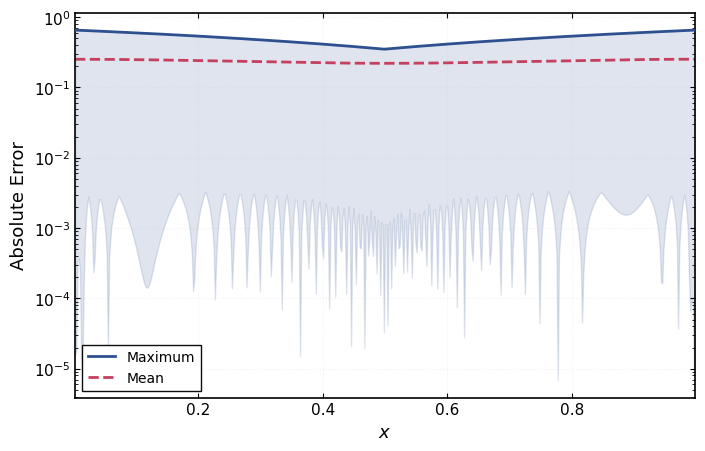

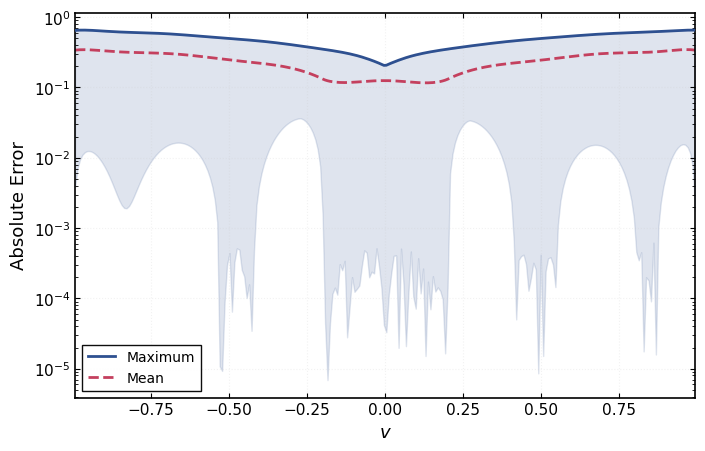

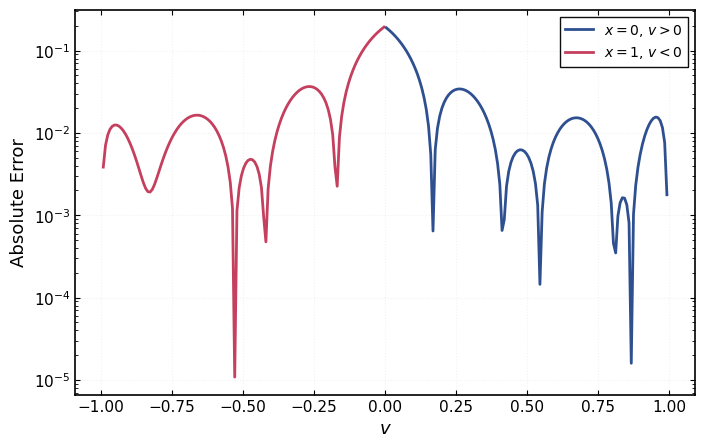

In [30]:
# ========== Error Distribution Visualization ==========
# Ensure numpy arrays are defined
mesh_x_np = np.asarray(mesh_x)
mesh_v_np = np.asarray(mesh_v)
F_np = np.asarray(F)
F_hat_np = np.asarray(F_hat)

# Ensure F and F_hat are numpy arrays
F = F_np
F_hat = F_hat_np

# Compute errors
error = np.abs(F - F_hat)

# Set academic plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
    "grid.linewidth": 0.8,
})

# Define unified professional color palette (blue-red scheme)
colors = {
    "primary": "#2E5090",  # Deep blue
    "secondary": "#C4405E",  # Deep rose
    "tertiary": "#5D8AA8",  # Steel blue
    "quaternary": "#A8717A",  # Dusty rose
    "grid": "#CCCCCC",
    "light_blue": "#7BA3C4",
    "light_red": "#D17A8D",
}

# ========== Figure 1: Error along x ==========
plt.figure(figsize=(8, 5))
error_max_x = np.max(error, axis=0)
error_mean_x = np.mean(error, axis=0)
error_min_x = np.min(error, axis=0)
plt.semilogy(
    mesh_x_np,
    error_max_x,
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
plt.semilogy(
    mesh_x_np,
    error_mean_x,
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
plt.fill_between(
    mesh_x_np, error_min_x, error_max_x, alpha=0.15, color=colors["primary"], zorder=1
)
plt.xlabel(r"$x$", fontsize=13)
plt.ylabel("Absolute Error", fontsize=13)
# plt.title("Error along x", fontsize=13, pad=8)
plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
plt.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax = plt.gca()
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.set_xlim([mesh_x_np[0], mesh_x_np[-1]])
plt.show()
plt.close()

# ========== Figure 2: Error along v ==========
plt.figure(figsize=(8, 5))
error_max_v = np.max(error, axis=1)
error_mean_v = np.mean(error, axis=1)
error_min_v = np.min(error, axis=1)
plt.semilogy(
    mesh_v_np,
    error_max_v,
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
plt.semilogy(
    mesh_v_np,
    error_mean_v,
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
plt.fill_between(
    mesh_v_np, error_min_v, error_max_v, alpha=0.15, color=colors["primary"], zorder=1
)
plt.xlabel(r"$v$", fontsize=13)
plt.ylabel("Absolute Error", fontsize=13)
# plt.title("Error along v", fontsize=13, pad=8)
plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
plt.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax = plt.gca()
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.set_xlim([mesh_v_np[0], mesh_v_np[-1]])
plt.show()
plt.close()

# ========== Figure 3: Boundary Errors Comparison ==========
plt.figure(figsize=(8, 5))
v_positive_idx = mesh_v_np >= 0
error_left = error[v_positive_idx, 0]
v_positive = mesh_v_np[v_positive_idx]
plt.semilogy(
    v_positive,
    error_left,
    "-",
    color=colors["primary"],
    linewidth=2,
    label=r"$x=0$, $v>0$",
    zorder=3,
)
v_negative_idx = mesh_v_np < 0
error_right = error[v_negative_idx, -1]
v_negative = mesh_v_np[v_negative_idx]
plt.semilogy(
    v_negative,
    error_right,
    "-",
    color=colors["secondary"],
    linewidth=2,
    label=r"$x=1$, $v<0$",
    zorder=2,
)
plt.xlabel(r"$v$", fontsize=13)
plt.ylabel("Absolute Error", fontsize=13)
# plt.title("Boundary Error Comparison", fontsize=13, pad=8)
plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
plt.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax = plt.gca()
ax.tick_params(direction="in", which="both", top=True, right=True)
plt.show()
plt.close()

# Reset matplotlib parameters
plt.rcParams.update(plt.rcParamsDefault)